## Home Task
Apply various clustering algorithms

- Agglomerative clustering using complete linkage
- Agglomerative clustering using single linkage
- DBSCAN
- Use albow method to determine the best k for Kmeans

In [2]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans

X, y = make_blobs(
    n_samples=500,
    n_features=2,
    centers=5,
    cluster_std=0.6,
    random_state=0
)

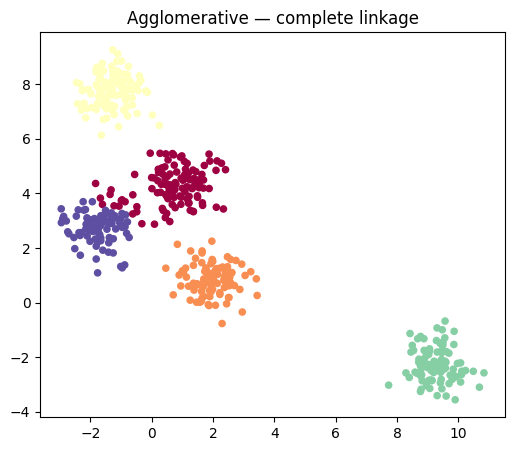

In [33]:
clf_complete = AgglomerativeClustering(
    n_clusters=5,
    linkage='complete'
)
labels_complete = clf_complete.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_complete, cmap='Spectral', s=20)
plt.title('Agglomerative — complete linkage')
plt.show()

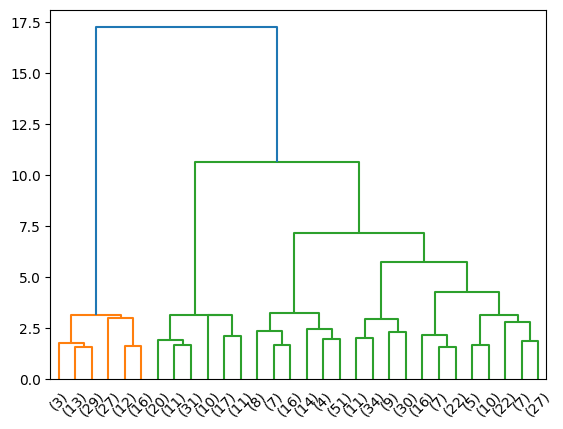

In [60]:
from scipy.cluster.hierarchy import dendrogram, linkage
linkage = linkage(X, 'complete')
dendrogram(linkage, truncate_mode='lastp')
plt.show()

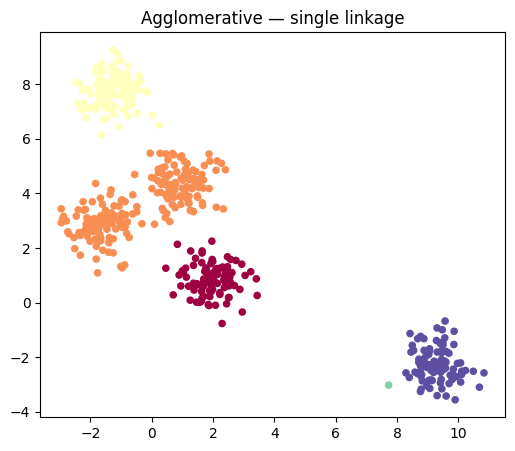

In [ ]:
clf_single = AgglomerativeClustering(
    n_clusters=5,
    linkage='single'
)
labels_single = clf_single.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_single, cmap='Spectral', s=20)
plt.title('Agglomerative — single linkage')
plt.show()

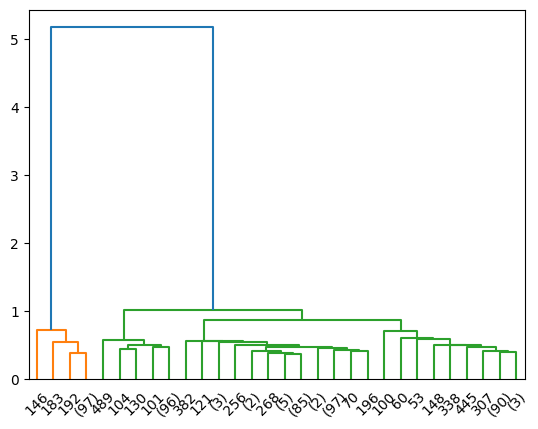

In [ ]:
linkage = linkage(X, 'single')
dendrogram(linkage, truncate_mode='lastp')
plt.show()


Clusters: 4, Noise: 3


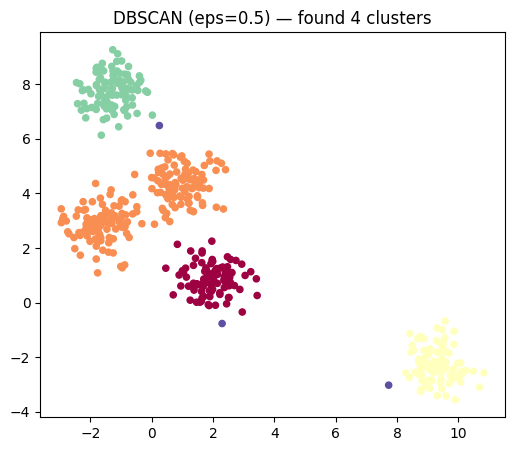

In [40]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
).fit(X)

labels_db = dbscan.labels_.copy()

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = list(labels_db).count(-1)
print(f'Clusters: {n_clusters}, Noise: {n_noise}')

labels_db[labels_db == -1] = n_clusters

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap='Spectral', s=20)
plt.title(f'DBSCAN (eps=0.5) — found {n_clusters} clusters')
plt.show()

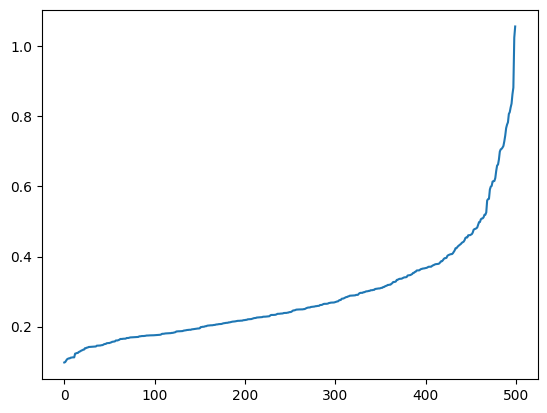

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
# k-distance graph: elbow method analog for dbscan for eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.show()


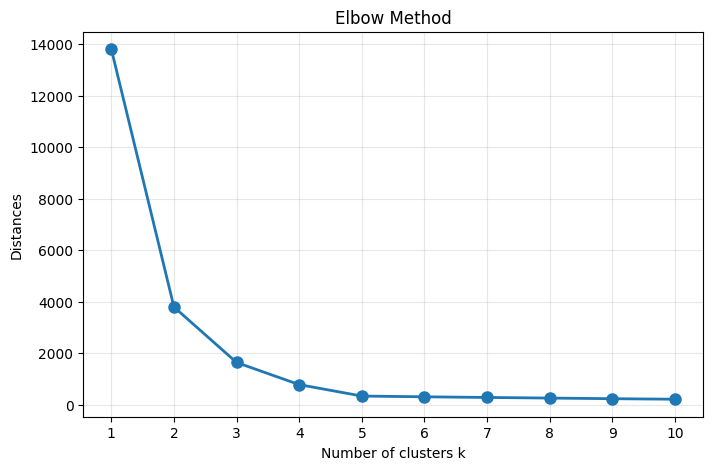

In [63]:
distances = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X)
    distances.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, linewidth=2,marker = 'o',markersize=8)
plt.xlabel('Number of clusters k')
plt.ylabel('Distances')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

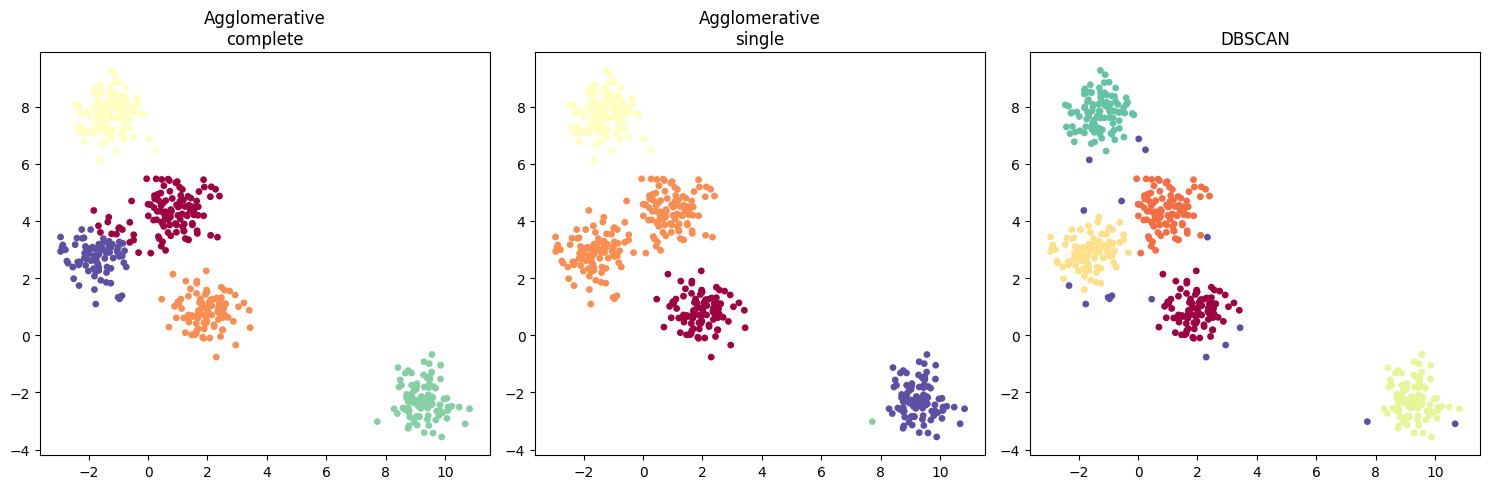

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X[:,0], X[:,1], c=labels_complete, cmap='Spectral', s=15)
axes[0].set_title('Agglomerative\ncomplete')

axes[1].scatter(X[:,0], X[:,1], c=labels_single, cmap='Spectral', s=15)
axes[1].set_title('Agglomerative\nsingle')

axes[2].scatter(X[:,0], X[:,1], c=labels_db, cmap='Spectral', s=15)
axes[2].set_title('DBSCAN')

plt.tight_layout()
plt.show()